In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/sales_data.csv')

print(df.head())

   Product_ID   Sale_Date Sales_Rep Region  Sales_Amount  Quantity_Sold  \
0        1052  03-02-2023       Bob  North       5053.97             18   
1        1093  21-04-2023       Bob   West       4384.02             17   
2        1015  21-09-2023     David  South       4631.23             30   
3        1072  24-08-2023       Bob  South       2167.94             39   
4        1061  24-03-2023   Charlie   East       3750.20             13   

  Product_Category  Unit_Cost  Unit_Price Customer_Type  Discount  \
0        Furniture     152.75      267.22     Returning      0.09   
1        Furniture    3816.39     4209.44     Returning      0.11   
2             Food     261.56      371.40     Returning      0.20   
3         Clothing    4330.03     4467.75           New      0.02   
4      Electronics     637.37      692.71           New      0.08   

  Payment_Method Sales_Channel Region_and_Sales_Rep  
0           Cash        Online            North-Bob  
1           Cash        Re

In [4]:
#Checking Missing Values
print(df.isnull().sum())


Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [6]:
#Fill Missing values
df.fillna(df.mean(numeric_only=True), inplace=True)#For numerical columns
df

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1010,15-04-2023,Charlie,North,4733.88,4,Food,4943.03,5442.15,Returning,0.29,Cash,Online,North-Charlie
996,1067,07-09-2023,Bob,North,4716.36,37,Clothing,1754.32,1856.40,New,0.21,Bank Transfer,Retail,North-Bob
997,1018,27-04-2023,David,South,7629.70,17,Clothing,355.72,438.27,Returning,0.06,Bank Transfer,Online,South-David
998,1100,20-12-2023,David,West,1629.47,39,Electronics,3685.03,3743.39,New,0.01,Bank Transfer,Online,West-David


In [7]:
#For Categorical columns
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1907/1771268793.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
#Remove duplicates records
before = len(df)

df.drop_duplicates(inplace=True)

after = len(df)

print("Duplicates Removed:", before-after)

Duplicates Removed: 0


In [9]:
#Generate Data cleaning report
report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Data Type": df.dtypes.values
})

print(report)

report.to_csv("Cleaning_Report.csv", index=False)

                  Column  Missing Values Data Type
0             Product_ID               0     int64
1              Sale_Date               0    object
2              Sales_Rep               0    object
3                 Region               0    object
4           Sales_Amount               0   float64
5          Quantity_Sold               0     int64
6       Product_Category               0    object
7              Unit_Cost               0   float64
8             Unit_Price               0   float64
9          Customer_Type               0    object
10              Discount               0   float64
11        Payment_Method               0    object
12         Sales_Channel               0    object
13  Region_and_Sales_Rep               0    object


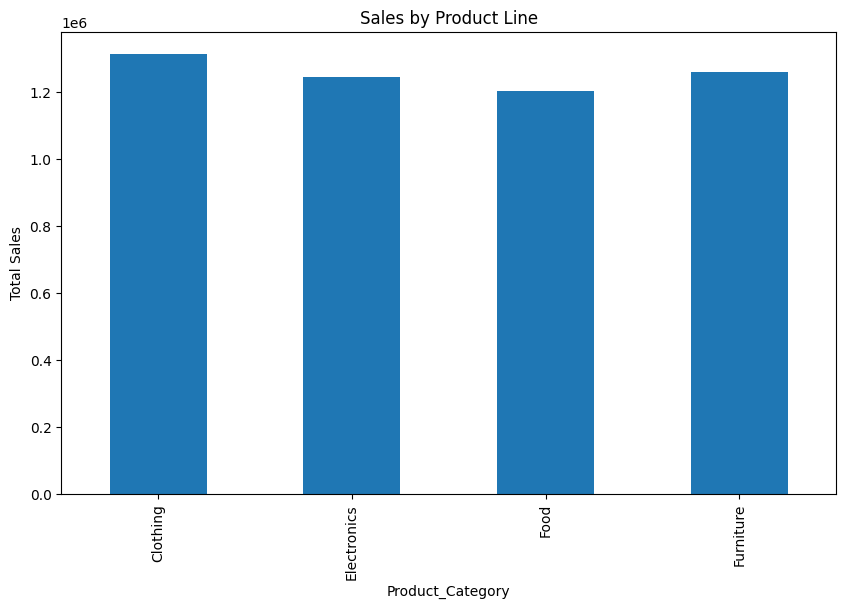

In [12]:
#Visualization
sales_summary = df.groupby('Product_Category')['Sales_Amount'].sum()
sales_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Sales by Product Line")
plt.ylabel("Total Sales")
plt.show()

In [13]:
#Generate automated excel report
with pd.ExcelWriter('Automated_Report.xlsx') as writer:

    df.to_excel(writer,
                sheet_name='Cleaned_Data',
                index=False)

    report.to_excel(writer,
                    sheet_name='Data_Quality_Report',
                    index=False)

In [14]:
#Save clean dataset
df.to_csv("Cleaned_Supermarket_Data.csv",
          index=False)